# 🏆 Football Goal Prediction — V10

**New improvements vs V9:**

| # | Perbaikan Baru V10 | Dampak Ekspektasi |
|---|---|---|
| A | **Multi-seed ensemble** (seeds 42, 123, 777) — average predictions dari 3 seed per booster | Variance ↓, stability ↑ |
| B | **Rolling windows 3, 15, 20** — tambah short-term (3 match) dan long-term (15, 20) form | Better signal granularity |
| C | **Elo win probability** — `P(win) = 1/(1 + 10^(-elo_diff/400))` sebagai feature terkalibrasi | Better outcome prediction |
| D | **Quality-adjusted attack/defense** — normalisasi scoring rate terhadap kualitas lawan | Lebih akurat λ estimation |
| E | **Pi-rating expected total & GD** — expected goals total dan goal difference dari π-rating | Direct score proxy |
| F | **Optuna 2-fold + 40 trials** — hyperparameter dari rata-rata 2 fold, bukan fold-0 saja | Better hyperparam estimate |
| G | **Nested 3-fold CV stacker** — LGB stacker dilatih dengan 3-fold CV untuk cegah overfitting | Generalization ↑ |
| H | **Draw correction post-processing** — ketika P(draw) tinggi + λ-diff kecil, paksa predict draw | Wrong outcome ↓ |
| I | **Tournament λ shrinkage** — blend λ ke tournament historical mean untuk match tidak pasti | Uncertainty handling |

Target: minimize AW-MAE < V9 (~2.8).


## 1. Setup & Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

from scipy.stats import poisson
from scipy.optimize import minimize_scalar, minimize
from sklearn.linear_model import Ridge
from sklearn.isotonic import IsotonicRegression
from sklearn.preprocessing import StandardScaler
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor
import joblib

pd.set_option('display.max_columns', 60)
plt.style.use('seaborn-v0_8-whitegrid')

# ── V10: Multi-seed ensemble ─────────────────────────────────────────────
SEED  = 42
SEEDS = [42, 123, 777]   # NEW V10: train each booster with 3 seeds

TRAIN_START_DATE = pd.Timestamp('1990-01-01')
MAX_GOALS = 8
MODEL_DIR = './models_v10'
os.makedirs(MODEL_DIR, exist_ok=True)

print('Libraries loaded ✓')
print(f'Optuna version: {optuna.__version__}')
print(f'Multi-seed ensemble: {SEEDS}')


Libraries loaded ✓
Optuna version: 4.6.0
Multi-seed ensemble: [42, 123, 777]


/home/pityudhistira28/.conda/envs/base2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Load Data & Apply Training-Era Cutoff

In [2]:
train = pd.read_csv('../dataset/train.csv')
test  = pd.read_csv('../dataset/test.csv')
gt    = pd.read_csv('../dataset/test_with_groundtruth.csv')

train['date'] = pd.to_datetime(train['date'])
test['date']  = pd.to_datetime(test['date'])

n_before = len(train)
train = train[train['date'] >= TRAIN_START_DATE].reset_index(drop=True)
n_after = len(train)

print(f'Train rows before cutoff: {n_before}')
print(f'Train rows after  cutoff: {n_after}  (dropped {n_before - n_after})')
print(f'Train : {train.shape}  |  Test : {test.shape}  |  GT : {gt.shape}')
print(f'Train date range: {train["date"].min().date()} → {train["date"].max().date()}')
print(f'Test  date range: {test["date"].min().date()}  → {test["date"].max().date()}')


Train rows before cutoff: 78772
Train rows after  cutoff: 43610  (dropped 35162)
Train : (43610, 47)  |  Test : (42422, 20)  |  GT : (42422, 22)
Train date range: 1990-01-12 → 2011-08-04
Test  date range: 2011-08-06  → 2026-03-31


## 3. Definisi Metrik Resmi AW-MAE (Unchanged)

In [3]:
def get_tournament_weight(tournament: str) -> float:
    t = str(tournament).lower().strip()
    if "fifa world cup" in t or t == "world cup": return 2.00
    if "afc championship" in t or "afc asian cup" in t or "asian cup" in t: return 1.80
    if "friendly" in t: return 0.96
    return 1.20

EXACT_PENALTY            = 0.30
OUTCOME_PENALTY          = 0.25
GD_PENALTY               = 0.15
WRONG_OUTCOME_MULTIPLIER = 1.50
NONLINEAR_POWER          = 1.50

def _outcome(a, b):
    if a > b: return  1
    if a < b: return -1
    return 0

def official_match_loss(y_team_true, y_opp_true, y_team_pred, y_opp_pred):
    y_team_true = np.asarray(y_team_true).astype(int)
    y_opp_true  = np.asarray(y_opp_true).astype(int)
    y_team_pred = np.asarray(y_team_pred).astype(int)
    y_opp_pred  = np.asarray(y_opp_pred).astype(int)
    base_mae = (np.abs(y_team_true - y_team_pred) + np.abs(y_opp_true - y_opp_pred)) / 2.0
    exact_hit    = (y_team_true == y_team_pred) & (y_opp_true == y_opp_pred)
    true_outcome = np.vectorize(_outcome)(y_team_true, y_opp_true)
    pred_outcome = np.vectorize(_outcome)(y_team_pred, y_opp_pred)
    outcome_hit  = (true_outcome == pred_outcome)
    gd_hit       = ((y_team_true - y_opp_true) == (y_team_pred - y_opp_pred))
    penalty = ((~exact_hit).astype(float)   * EXACT_PENALTY +
               (~outcome_hit).astype(float) * OUTCOME_PENALTY +
               (~gd_hit).astype(float)      * GD_PENALTY)
    raw_error = base_mae + penalty
    raw_error = np.where(outcome_hit, raw_error, raw_error * WRONG_OUTCOME_MULTIPLIER)
    return raw_error ** NONLINEAR_POWER

def awmae_score(y_team_true, y_opp_true, y_team_pred, y_opp_pred, weights=None) -> float:
    losses = official_match_loss(y_team_true, y_opp_true, y_team_pred, y_opp_pred)
    if weights is None: weights = np.ones(len(losses), dtype=float)
    else: weights = np.asarray(weights, dtype=float)
    return float(np.average(losses, weights=weights))

print('AW-MAE metric defined ✓')


AW-MAE metric defined ✓


## 4. Feature Engineering V10

**New in V10:**
- Rolling windows 3, 15, 20 matches (short & long-term form)
- Elo win probability (calibrated P(win) from Elo)
- Quality-adjusted attack/defense (normalize by opponent strength)
- Pi-rating expected total goals and expected goal difference


In [4]:
def add_time_features(df):
    df = df.copy()
    df['date'] = pd.to_datetime(df['date'])
    df['year']       = df['date'].dt.year.astype(int)
    df['month']      = df['date'].dt.month.astype(int)
    df['quarter']    = df['date'].dt.quarter.astype(int)
    df['dayofweek']  = df['date'].dt.dayofweek.astype(int)
    df['dayofyear']  = df['date'].dt.dayofyear.astype(int)
    df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)
    df['month_sin']  = np.sin(2 * np.pi * df['month'] / 12.0)
    df['month_cos']  = np.cos(2 * np.pi * df['month'] / 12.0)
    df['dow_sin']    = np.sin(2 * np.pi * df['dayofweek'] / 7.0)
    df['dow_cos']    = np.cos(2 * np.pi * df['dayofweek'] / 7.0)
    df['doy_sin']    = np.sin(2 * np.pi * df['dayofyear'] / 366.0)
    df['doy_cos']    = np.cos(2 * np.pi * df['dayofyear'] / 366.0)
    return df

def assign_tournament_importance(name):
    if not isinstance(name, str) or name.strip() == '': return 1
    n = name.lower()
    if 'fifa world cup' in n and 'qualif' not in n: return 5
    tier4 = ['uefa euro','copa américa','copa america','african cup of nations',
             'africa cup of nations','afc asian cup','gold cup','concacaf championship',
             'ofc nations cup','oceania nations cup','confederations cup']
    if any(k in n for k in tier4) and 'qualif' not in n: return 4
    if 'qualif' in n or 'nations league' in n or 'olympic' in n: return 3
    tier2 = ['cecafa','cosafa','cfu caribbean','gulf cup','aff championship',
             'southeast asian',"king's cup",'merdeka','island games','asian games',
             'south asian','baltic cup','nordic championship','british home championship',
             'algarve cup','cyprus cup','shebelieves','tournament','cup']
    if any(k in n for k in tier2): return 2
    return 1

print('Time + tournament features defined ✓')


Time + tournament features defined ✓


In [5]:
def build_last_known_rank(raw_train_df):
    raw = raw_train_df.copy()
    raw['date'] = pd.to_datetime(raw['date'])
    team_side = (raw[['date','team','rank_team','confederation_team']]
                 .rename(columns={'team':'name','rank_team':'rank','confederation_team':'conf'})
                 .dropna(subset=['rank']))
    opp_side  = (raw[['date','opponent','rank_opponent','confederation_opp']]
                 .rename(columns={'opponent':'name','rank_opponent':'rank','confederation_opp':'conf'})
                 .dropna(subset=['rank']))
    stacked = pd.concat([team_side, opp_side], ignore_index=True).sort_values('date')
    last_rank = (stacked.groupby('name').last()[['rank','conf']].rename(columns={'rank':'last_rank'}))
    conf_median = last_rank.groupby('conf')['last_rank'].median()
    last_rank['conf_median_rank'] = last_rank['conf'].map(conf_median)
    last_rank['last_rank_filled'] = last_rank['last_rank'].fillna(
        last_rank['conf_median_rank']).fillna(last_rank['last_rank'].median())
    return last_rank[['last_rank_filled']].to_dict()['last_rank_filled']

_raw_train_for_rank = pd.read_csv('../dataset/train.csv')
RANK_LOOKUP = build_last_known_rank(_raw_train_for_rank)
GLOBAL_MEDIAN_RANK = np.median(list(RANK_LOOKUP.values()))
print(f'Rank lookup built: {len(RANK_LOOKUP)} teams  |  global median rank: {GLOBAL_MEDIAN_RANK:.0f}')


Rank lookup built: 201 teams  |  global median rank: 102


In [6]:
def _match_outcome_cols(df):
    df = df.copy()
    tg = df['team_goals'].astype(float); og = df['opp_goals'].astype(float)
    df['_points'] = np.where(tg > og, 3, np.where(tg == og, 1, 0))
    df['_gd']     = tg - og
    df['_win']    = (tg > og).astype(float)
    df['_draw']   = (tg == og).astype(float)
    df['_loss']   = (tg < og).astype(float)
    df['_total']  = tg + og
    return df


def add_rolling_team_features(df):
    """V10: added windows 3, 15, 20 for richer form signals."""
    df = _match_outcome_cols(df)

    def lr(col, window, op):
        return df.groupby('team', sort=False)[col].transform(
            lambda s: s.shift(1).rolling(window, min_periods=1).agg(op))

    # ── Original windows ────────────────────────────────────────────────
    df['team_points_last5']        = lr('_points', 5,  'sum')
    df['team_points_last10']       = lr('_points', 10, 'sum')
    df['team_gd_last5']            = lr('_gd', 5, 'sum')
    df['team_gd_last10']           = lr('_gd', 10, 'sum')
    df['team_avg_goals_last5']     = lr('team_goals', 5,  'mean')
    df['team_avg_conceded_last5']  = lr('opp_goals',  5,  'mean')
    df['team_win_rate_last10']     = lr('_win', 10, 'mean')

    # ── NEW V10: Short-term (3-match) – captures very recent form ───────
    df['team_points_last3']        = lr('_points', 3, 'sum')
    df['team_avg_goals_last3']     = lr('team_goals', 3, 'mean')
    df['team_avg_conceded_last3']  = lr('opp_goals',  3, 'mean')
    df['team_win_rate_last3']      = lr('_win', 3, 'mean')
    df['team_total_goals_last3']   = lr('_total', 3, 'mean')

    # ── NEW V10: Mid-term (15-match) ────────────────────────────────────
    df['team_avg_goals_last15']    = lr('team_goals', 15, 'mean')
    df['team_avg_conceded_last15'] = lr('opp_goals',  15, 'mean')
    df['team_win_rate_last15']     = lr('_win', 15, 'mean')

    # ── NEW V10: Long-term (20-match) – baseline form ───────────────────
    df['team_avg_goals_last20']    = lr('team_goals', 20, 'mean')
    df['team_avg_conceded_last20'] = lr('opp_goals',  20, 'mean')
    df['team_win_rate_last20']     = lr('_win', 20, 'mean')
    df['team_total_goals_last20']  = lr('_total', 20, 'mean')
    df['team_points_last20']       = lr('_points', 20, 'sum')

    # ── NEW V10: Total goals rolling (both score) ────────────────────────
    df['team_total_goals_last5']   = lr('_total', 5, 'mean')
    df['team_total_goals_last10']  = lr('_total', 10, 'mean')

    # ── Days since last match ────────────────────────────────────────────
    df['days_since_last_match_team'] = df.groupby('team', sort=False)['date'].transform(
        lambda s: (s - s.shift(1)).dt.days)

    # ── Streak features (V5/V9 style) ───────────────────────────────────
    for col_name, result_col in [('streak_win','_win'),('streak_loss','_loss'),('streak_draw','_draw')]:
        df[f'team_{col_name}'] = df.groupby('team', sort=False)[result_col].transform(
            lambda s: (
                s.shift(1).groupby((s.shift(1) != s.shift(1).shift(1)).cumsum()).cumcount() + 1
            ) * s.shift(1)
        ).fillna(0)

    return df


def add_opponent_side_features(df):
    pairs = [
        ('team_points_last5',        'opp_points_last5'),
        ('team_points_last10',       'opp_points_last10'),
        ('team_points_last3',        'opp_points_last3'),
        ('team_points_last20',       'opp_points_last20'),
        ('team_gd_last5',            'opp_gd_last5'),
        ('team_gd_last10',           'opp_gd_last10'),
        ('team_avg_goals_last5',     'opp_avg_goals_last5'),
        ('team_avg_conceded_last5',  'opp_avg_conceded_last5'),
        ('team_avg_goals_last3',     'opp_avg_goals_last3'),
        ('team_avg_conceded_last3',  'opp_avg_conceded_last3'),
        ('team_avg_goals_last15',    'opp_avg_goals_last15'),
        ('team_avg_conceded_last15', 'opp_avg_conceded_last15'),
        ('team_avg_goals_last20',    'opp_avg_goals_last20'),
        ('team_avg_conceded_last20', 'opp_avg_conceded_last20'),
        ('team_win_rate_last10',     'opp_win_rate_last10'),
        ('team_win_rate_last3',      'opp_win_rate_last3'),
        ('team_win_rate_last15',     'opp_win_rate_last15'),
        ('team_win_rate_last20',     'opp_win_rate_last20'),
        ('team_total_goals_last5',   'opp_total_goals_last5'),
        ('team_total_goals_last10',  'opp_total_goals_last10'),
        ('team_total_goals_last20',  'opp_total_goals_last20'),
        ('days_since_last_match_team','days_since_last_match_opp'),
        ('team_streak_win',          'opp_streak_win'),
        ('team_streak_loss',         'opp_streak_loss'),
        ('team_streak_draw',         'opp_streak_draw'),
    ]
    src = ['match_id','team'] + [p[0] for p in pairs if p[0] in df.columns]
    actual_pairs = [(p[0], p[1]) for p in pairs if p[0] in df.columns]
    mirror = df[src].rename(columns={'team':'opponent', **{p[0]:p[1] for p in actual_pairs}})
    return df.merge(mirror, on=['match_id','opponent'], how='left')


def add_h2h_features(df):
    df = df.copy()
    g = df.groupby(['team','opponent'], sort=False)
    df['h2h_points_last5']         = g['_points'].transform(lambda s: s.shift(1).rolling(5, min_periods=1).sum())
    df['h2h_gd_last5']             = g['_gd'].transform(lambda s: s.shift(1).rolling(5, min_periods=1).sum())
    df['h2h_points_last10']        = g['_points'].transform(lambda s: s.shift(1).rolling(10, min_periods=1).sum())
    df['h2h_gd_last10']            = g['_gd'].transform(lambda s: s.shift(1).rolling(10, min_periods=1).sum())
    df['h2h_win_rate_last10']      = g['_win'].transform(lambda s: s.shift(1).rolling(10, min_periods=1).mean())
    df['h2h_goals_scored_last10']  = g['team_goals'].transform(lambda s: s.shift(1).rolling(10, min_periods=1).mean())
    df['h2h_goals_conceded_last10']= g['opp_goals'].transform(lambda s: s.shift(1).rolling(10, min_periods=1).mean())
    df['h2h_points_all']           = g['_points'].transform(lambda s: s.shift(1).expanding(1).sum())
    df['h2h_gd_all']               = g['_gd'].transform(lambda s: s.shift(1).expanding(1).sum())
    n_matches = g['_win'].transform('count').clip(lower=1)
    df['h2h_dominance']            = df['h2h_points_all'] / n_matches
    return df

print('Rolling + H2H feature functions defined ✓ (V10: added windows 3, 15, 20)')


Rolling + H2H feature functions defined ✓ (V10: added windows 3, 15, 20)


In [7]:
def _elo_match_weight_K(tournament, match_date):
    if not isinstance(tournament, str): return 30
    n = tournament.lower()
    if 'olympic' in n:
        year = pd.Timestamp(match_date).year
        return 60 if 1908 <= year <= 1980 else 30
    if 'fifa world cup' in n and 'qualif' not in n: return 60
    tier50 = ['uefa euro','copa américa','copa america','african cup of nations',
              'africa cup of nations','afc asian cup','gold cup','concacaf championship',
              'ofc nations cup','oceania nations cup','confederations cup']
    if any(k in n for k in tier50) and 'qualif' not in n: return 50
    if 'qualif' in n: return 40
    if 'nations league' in n: return 40
    if 'friendly' in n: return 20
    return 30

def _elo_goal_diff_multiplier(gd):
    gd = int(abs(gd))
    if gd <= 1: return 1.0
    if gd == 2: return 1.5
    return (11.0 + gd) / 8.0

ELO_HOME_ADV = 100.0

def add_elo_features(df, initial=1500.0, home_adv=ELO_HOME_ADV):
    df = df.copy()
    elo_per_gender = {'M': {}, 'W': {}}
    pre_elo = {}
    first_rows = (df.drop_duplicates('match_id', keep='first')
                    .sort_values(['date','match_id']).reset_index(drop=True))
    for row in first_rows.itertuples(index=False):
        elo = elo_per_gender.get(row.gender)
        if elo is None: continue
        R_team = elo.get(row.team, initial); R_opp = elo.get(row.opponent, initial)
        pre_elo[(row.match_id, row.team)]     = R_team
        pre_elo[(row.match_id, row.opponent)] = R_opp
        tg, og = row.team_goals, row.opp_goals
        if pd.isna(tg) or pd.isna(og): continue
        tg, og = int(tg), int(og)
        HA = 0.0 if row.neutral else (+home_adv if row.is_home == 1 else -home_adv)
        dr = R_team - R_opp + HA
        We = 1.0 / (10 ** (-dr / 400.0) + 1.0)
        W = 1.0 if tg > og else (0.0 if tg < og else 0.5)
        K = _elo_match_weight_K(row.tournament, row.date)
        G = _elo_goal_diff_multiplier(tg - og)
        P = round(K * G * (W - We))
        elo[row.team] = R_team + P; elo[row.opponent] = R_opp - P
    pre_elo_df = pd.DataFrame([(mid, name, val) for (mid, name), val in pre_elo.items()],
                               columns=['match_id','_name','elo'])
    df = df.merge(pre_elo_df.rename(columns={'_name':'team','elo':'elo_team'}),
                  on=['match_id','team'], how='left')
    df = df.merge(pre_elo_df.rename(columns={'_name':'opponent','elo':'elo_opponent'}),
                  on=['match_id','opponent'], how='left')
    df['elo_team']     = df['elo_team'].fillna(initial)
    df['elo_opponent'] = df['elo_opponent'].fillna(initial)
    return df

def _pi_error_smooth(e):
    return 3.0 * np.log10(1.0 + abs(e)) * np.sign(e)

def add_pi_rating_features(df, lambda_w=0.06, gamma_w=0.5, initial=0.0):
    df = df.copy()
    pi_home = {'M': {}, 'W': {}}; pi_away = {'M': {}, 'W': {}}
    pre = {}
    first_rows = (df.drop_duplicates('match_id', keep='first')
                    .sort_values(['date','match_id']).reset_index(drop=True))
    for row in first_rows.itertuples(index=False):
        g = row.gender
        if g not in pi_home: continue
        team, opp = row.team, row.opponent
        H_t = pi_home[g].get(team, initial); A_t = pi_away[g].get(team, initial)
        H_o = pi_home[g].get(opp, initial);  A_o = pi_away[g].get(opp, initial)
        pre[(row.match_id, team)] = (H_t, A_t)
        pre[(row.match_id, opp)]  = (H_o, A_o)
        tg, og = row.team_goals, row.opp_goals
        if pd.isna(tg) or pd.isna(og): continue
        tg, og = int(tg), int(og)
        if row.neutral:       expected_gd = 0.5 * ((H_t - A_o) + (A_t - H_o))
        elif row.is_home == 1: expected_gd = H_t - A_o
        else:                  expected_gd = A_t - H_o
        error = (tg - og) - expected_gd
        delta = lambda_w * _pi_error_smooth(error)
        if row.neutral:
            pi_home[g][team] = H_t + 0.5*delta; pi_away[g][team] = A_t + 0.5*delta
            pi_home[g][opp]  = H_o - 0.5*delta; pi_away[g][opp]  = A_o - 0.5*delta
        elif row.is_home == 1:
            new_H_t = H_t + delta
            pi_home[g][team] = new_H_t; pi_away[g][team] = A_t + gamma_w*(new_H_t - H_t)
            new_A_o = A_o - delta
            pi_away[g][opp] = new_A_o; pi_home[g][opp] = H_o + gamma_w*(new_A_o - A_o)
        else:
            new_A_t = A_t + delta
            pi_away[g][team] = new_A_t; pi_home[g][team] = H_t + gamma_w*(new_A_t - A_t)
            new_H_o = H_o - delta
            pi_home[g][opp] = new_H_o; pi_away[g][opp] = A_o + gamma_w*(new_H_o - H_o)
    pre_df = pd.DataFrame([(mid, name, h, a) for (mid, name), (h, a) in pre.items()],
                           columns=['match_id','_name','pi_home','pi_away'])
    df = df.merge(pre_df.rename(columns={'_name':'team','pi_home':'pi_home_team','pi_away':'pi_away_team'}),
                  on=['match_id','team'], how='left')
    df = df.merge(pre_df.rename(columns={'_name':'opponent','pi_home':'pi_home_opp','pi_away':'pi_away_opp'}),
                  on=['match_id','opponent'], how='left')
    for c in ['pi_home_team','pi_away_team','pi_home_opp','pi_away_opp']:
        df[c] = df[c].fillna(initial)
    return df

print('Elo + Pi-rating feature functions defined ✓')


Elo + Pi-rating feature functions defined ✓


In [8]:
RECONSTRUCTED_COLS = [
    'team_points_last5','team_points_last10','team_points_last3','team_points_last20',
    'opp_points_last5','opp_points_last10','opp_points_last3','opp_points_last20',
    'team_gd_last5','team_gd_last10','opp_gd_last5','opp_gd_last10',
    'team_avg_goals_last5','team_avg_conceded_last5',
    'team_avg_goals_last3','team_avg_conceded_last3',
    'team_avg_goals_last15','team_avg_conceded_last15',
    'team_avg_goals_last20','team_avg_conceded_last20',
    'opp_avg_goals_last5','opp_avg_conceded_last5',
    'opp_avg_goals_last3','opp_avg_conceded_last3',
    'opp_avg_goals_last15','opp_avg_conceded_last15',
    'opp_avg_goals_last20','opp_avg_conceded_last20',
    'team_win_rate_last10','opp_win_rate_last10',
    'team_win_rate_last3','opp_win_rate_last3',
    'team_win_rate_last15','opp_win_rate_last15',
    'team_win_rate_last20','opp_win_rate_last20',
    'team_total_goals_last5','opp_total_goals_last5',
    'team_total_goals_last10','opp_total_goals_last10',
    'team_total_goals_last20','opp_total_goals_last20',
    'points_last5_diff','gd_last5_diff',
    'h2h_points_last5','h2h_gd_last5',
    'h2h_points_last10','h2h_gd_last10',
    'h2h_win_rate_last10','h2h_goals_scored_last10','h2h_goals_conceded_last10',
    'h2h_points_all','h2h_gd_all','h2h_dominance',
    'days_since_last_match_team','days_since_last_match_opp',
    'elo_team','elo_opponent',
    'pi_home_team','pi_away_team','pi_home_opp','pi_away_opp',
    'team_streak_win','team_streak_loss','team_streak_draw',
    'opp_streak_win','opp_streak_loss','opp_streak_draw',
]

def reconstruct_core_features(train_df, test_df, gt_df):
    gt_cols = gt_df[['Id','team_goals','opp_goals']].copy()
    test_w_gt = test_df.merge(gt_cols, on='Id', how='left')
    tr = train_df.drop(columns=[c for c in RECONSTRUCTED_COLS if c in train_df.columns], errors='ignore')
    common = ['Id','match_id','date','gender','team','opponent',
              'is_home','neutral','tournament','team_goals','opp_goals']
    tr_core = tr[common].copy(); tr_core['_split'] = 'train'
    te_core = test_w_gt[common].copy(); te_core['_split'] = 'test'
    hist = pd.concat([tr_core, te_core], ignore_index=True)
    hist['date'] = pd.to_datetime(hist['date'])
    hist = hist.sort_values(['date','match_id','is_home'], ascending=[True,True,False]).reset_index(drop=True)
    hist = add_rolling_team_features(hist)
    hist = add_opponent_side_features(hist)
    hist['points_last5_diff'] = hist['team_points_last5'] - hist['opp_points_last5']
    hist['gd_last5_diff']     = hist['team_gd_last5']     - hist['opp_gd_last5']
    hist = add_h2h_features(hist)
    hist = add_elo_features(hist)
    hist = add_pi_rating_features(hist)
    hist['tournament_importance'] = hist['tournament'].map(assign_tournament_importance)
    hist = hist.drop(columns=[c for c in ['_points','_gd','_win','_draw','_loss','_total'] if c in hist.columns])
    new_cols = RECONSTRUCTED_COLS + ['tournament_importance']
    tr_out = train_df.drop(columns=[c for c in new_cols if c in train_df.columns], errors='ignore').merge(
        hist.loc[hist['_split']=='train', ['Id'] + new_cols], on='Id', how='left')
    te_out = test_df.merge(
        hist.loc[hist['_split']=='test', ['Id'] + new_cols], on='Id', how='left')
    return tr_out, te_out

def build_history_pack(train_df):
    tr = add_time_features(train_df)
    tr = tr.sort_values(['date','match_id','team']).copy()
    team_hist = (tr.groupby('team')
                   .agg(team_hist_avg_goals=('team_goals','mean'),
                        team_hist_avg_conceded=('opp_goals','mean'),
                        team_hist_std_goals=('team_goals','std'),
                        team_hist_matches=('match_id','nunique'))
                   .reset_index())
    tournament_hist = (tr.groupby('tournament')
                         .agg(tournament_avg_goals=('team_goals','mean'),
                              tournament_avg_total=('team_goals',
                                  lambda s: (s + tr.loc[s.index,'opp_goals']).mean()))
                         .reset_index())
    venue_hist = (tr.groupby('venue_country')
                    .agg(venue_avg_goals=('team_goals','mean'),
                         venue_avg_total=('team_goals',
                             lambda s: (s + tr.loc[s.index,'opp_goals']).mean()))
                    .reset_index())
    conf_hist = (tr.groupby('confederation_team')
                   .agg(conf_team_avg_goals=('team_goals','mean'),
                        conf_team_avg_conceded=('opp_goals','mean'))
                   .reset_index())
    gender_hist = (tr.groupby('gender')
                     .agg(gender_avg_goals=('team_goals','mean'),
                          gender_avg_total=('team_goals',
                              lambda s: (s + tr.loc[s.index,'opp_goals']).mean()))
                     .reset_index())
    return {'team_hist':team_hist,'tournament_hist':tournament_hist,
            'venue_hist':venue_hist,'conf_hist':conf_hist,'gender_hist':gender_hist}

print('Feature orchestrator defined ✓')


Feature orchestrator defined ✓


In [9]:
# Global stats for quality-adjustment (computed after data is loaded)
_GLOBAL_AVG_GOALS    = 1.35   # approximate; will be recomputed from training data
_GLOBAL_AVG_CONCEDED = 1.35

def engineer_features(df, history_pack, global_avg_goals=None, global_avg_conceded=None):
    """V10: adds Elo win prob, quality-adjusted attack/defense, pi expected GD/total."""
    if global_avg_goals is None:    global_avg_goals    = _GLOBAL_AVG_GOALS
    if global_avg_conceded is None: global_avg_conceded = _GLOBAL_AVG_CONCEDED
    d = add_time_features(df).copy()

    if 'altitude_venue' in d.columns:
        d['altitude_venue'] = d['altitude_venue'].replace(-9999, np.nan)

    d['tournament_weight'] = d['tournament'].apply(get_tournament_weight)
    d = d.merge(history_pack['team_hist'], on='team', how='left')
    opp_team_hist = history_pack['team_hist'].rename(columns={
        'team':'opponent',
        'team_hist_avg_goals':'opp_hist_avg_goals',
        'team_hist_avg_conceded':'opp_hist_avg_conceded',
        'team_hist_std_goals':'opp_hist_std_goals',
        'team_hist_matches':'opp_hist_matches'})
    d = d.merge(opp_team_hist, on='opponent', how='left')
    d = d.merge(history_pack['tournament_hist'], on='tournament', how='left')
    d = d.merge(history_pack['venue_hist'],      on='venue_country', how='left')
    d = d.merge(history_pack['conf_hist'],       on='confederation_team', how='left')
    d = d.merge(history_pack['gender_hist'],     on='gender', how='left')

    # ── Rank features ────────────────────────────────────────────────────
    d['rank_proxy_team']         = d['team'].map(RANK_LOOKUP).fillna(GLOBAL_MEDIAN_RANK)
    d['rank_proxy_opp']          = d['opponent'].map(RANK_LOOKUP).fillna(GLOBAL_MEDIAN_RANK)
    d['rank_proxy_diff']         = d['rank_proxy_team'] - d['rank_proxy_opp']
    d['rank_proxy_gap']          = np.abs(d['rank_proxy_diff'])
    d['rank_proxy_missing_team'] = (~d['team'].isin(RANK_LOOKUP)).astype(int)
    d['rank_proxy_missing_opp']  = (~d['opponent'].isin(RANK_LOOKUP)).astype(int)

    # ── Elo-derived ──────────────────────────────────────────────────────
    d['elo_diff']    = d['elo_team'] - d['elo_opponent']
    d['elo_sum']     = d['elo_team'] + d['elo_opponent']
    d['elo_gap_abs'] = np.abs(d['elo_diff'])

    # ── NEW V10: Elo win probability (calibrated) ────────────────────────
    # Adjusted for home advantage; this is the well-calibrated P(win) from Elo system
    home_adj = ELO_HOME_ADV * d['is_home'] * (1 - d['neutral'])
    elo_adj   = d['elo_diff'] + home_adj
    d['elo_win_prob_team'] = 1.0 / (1.0 + 10.0 ** (-elo_adj / 400.0))
    d['elo_draw_prob_proxy'] = np.exp(-np.abs(elo_adj) / 200.0)   # draw more likely when teams close
    d['elo_expected_gd']  = elo_adj / 400.0 * 2.0   # rough Elo-based expected GD

    # ── Pi-rating-derived ────────────────────────────────────────────────
    d['pi_effective_team'] = np.where(d['neutral']==1, 0.5*(d['pi_home_team']+d['pi_away_team']),
                             np.where(d['is_home']==1, d['pi_home_team'], d['pi_away_team']))
    d['pi_effective_opp']  = np.where(d['neutral']==1, 0.5*(d['pi_home_opp']+d['pi_away_opp']),
                             np.where(d['is_home']==1, d['pi_away_opp'], d['pi_home_opp']))
    d['pi_diff']     = d['pi_effective_team'] - d['pi_effective_opp']
    d['pi_gap_abs']  = np.abs(d['pi_diff'])

    # ── NEW V10: Pi expected total / GD ─────────────────────────────────
    # Pi sum ≈ proxy for how exciting / high-scoring the match will be
    d['pi_sum']           = d['pi_effective_team'] + d['pi_effective_opp']
    d['pi_expected_gd']   = d['pi_diff']
    d['pi_expected_total'] = np.abs(d['pi_sum']) + 2.0   # rough proxy: higher pi → higher total

    # ── Form interactions ────────────────────────────────────────────────
    d['rest_diff']          = d['days_since_last_match_team'] - d['days_since_last_match_opp']
    d['rest_sum']           = d['days_since_last_match_team'] + d['days_since_last_match_opp']
    d['goal_form_diff']     = d['team_avg_goals_last5'] - d['opp_avg_goals_last5']
    d['conceded_form_diff'] = d['team_avg_conceded_last5'] - d['opp_avg_conceded_last5']
    d['attack_vs_defense']  = d['team_avg_goals_last5'] - d['opp_avg_conceded_last5']
    d['defense_vs_attack']  = d['opp_avg_goals_last5']  - d['team_avg_conceded_last5']
    d['winrate_diff']       = d['team_win_rate_last10'] - d['opp_win_rate_last10']
    d['h2h_strength']       = d['h2h_points_last5'] + 0.25 * d['h2h_gd_last5']
    d['h2h_strength_wide']  = d.get('h2h_points_last10', pd.Series(0, index=d.index)).fillna(0) \
                              + 0.25 * d.get('h2h_gd_last10', pd.Series(0, index=d.index)).fillna(0)

    # ── NEW V10: Multi-window form diff ──────────────────────────────────
    d['goal_form_diff_3']   = d['team_avg_goals_last3']  - d['opp_avg_goals_last3']
    d['goal_form_diff_20']  = d['team_avg_goals_last20'] - d['opp_avg_goals_last20']
    d['winrate_diff_3']     = d['team_win_rate_last3']   - d['opp_win_rate_last3']
    d['winrate_diff_20']    = d['team_win_rate_last20']  - d['opp_win_rate_last20']
    d['points_diff_3']      = d['team_points_last3']     - d['opp_points_last3']
    d['points_diff_20']     = d['team_points_last20']    - d['opp_points_last20']

    # ── NEW V10: Quality-adjusted attack/defense ─────────────────────────
    # Normalize team's recent goals by the quality of defenses they've faced
    # opp_hist_avg_conceded = how many goals the OPPONENT team historically concedes per match
    # attack_adj = goals scored / opp_defense_quality * global_mean → what would team score vs avg defense?
    eps = 0.1
    d['attack_adj'] = (
        d['team_avg_goals_last5'] /
        d['opp_hist_avg_conceded'].clip(lower=eps).fillna(global_avg_conceded) *
        global_avg_conceded
    )
    d['defense_adj'] = (
        d['team_avg_conceded_last5'] /
        d['opp_hist_avg_goals'].clip(lower=eps).fillna(global_avg_goals) *
        global_avg_goals
    )
    # Attack/defense gap (how much better at attack vs opponent's defense adjustment)
    opp_attack_adj = (
        d['opp_avg_goals_last5'] /
        d['team_hist_avg_conceded'].clip(lower=eps).fillna(global_avg_conceded) *
        global_avg_conceded
    )
    opp_defense_adj = (
        d['opp_avg_conceded_last5'] /
        d['team_hist_avg_goals'].clip(lower=eps).fillna(global_avg_goals) *
        global_avg_goals
    )
    d['attack_adj_diff']   = d['attack_adj'] - opp_attack_adj
    d['defense_adj_diff']  = opp_defense_adj - d['defense_adj']   # positive = team defends better
    d['net_quality_adj']   = d['attack_adj_diff'] + d['defense_adj_diff']

    # ── Tournament features ──────────────────────────────────────────────
    d['same_confederation'] = (d['confederation_team'] == d['confederation_opp']).astype(int)
    d['major_tournament']   = (d['tournament_weight'] >= 1.8).astype(int)
    d['home_x_elo']         = d['is_home'] * d['elo_diff']
    d['neutral_x_elo']      = d['neutral'] * d['elo_diff']
    d['home_x_pi']          = d['is_home'] * d['pi_diff']
    d['neutral_x_pi']       = d['neutral'] * d['pi_diff']
    d['travel_diff']        = d['distance_travel_team']  - d['distance_travel_opp']
    d['population_diff']    = d['population_team']       - d['population_opp']
    d['gdp_diff']           = d['gdp_per_capita_team']   - d['gdp_per_capita_opp']
    d['temperature_home']   = d['temperature_venue'] * d['is_home']

    # ── Altitude ────────────────────────────────────────────────────────
    d['altitude_home_adv']    = d['altitude_venue'].fillna(0) * d['is_home']
    d['altitude_away_disadv'] = d['altitude_venue'].fillna(0) * (1 - d['is_home']) * (1 - d['neutral'])

    # ── Interaction features ─────────────────────────────────────────────
    d['pi_diff_x_tournament']  = d['pi_diff'] * d['tournament_importance']
    d['elo_diff_x_tournament'] = d['elo_diff'] * d['tournament_importance']
    d['rank_x_elo_diff']       = d['rank_proxy_diff'] * d['elo_diff']
    d['streak_win_diff']   = d.get('team_streak_win',  pd.Series(0,index=d.index)).fillna(0) \
                           - d.get('opp_streak_win',   pd.Series(0,index=d.index)).fillna(0)
    d['streak_loss_diff']  = d.get('team_streak_loss', pd.Series(0,index=d.index)).fillna(0) \
                           - d.get('opp_streak_loss',  pd.Series(0,index=d.index)).fillna(0)
    d['form_momentum']     = d['team_points_last5'] - (d['team_points_last10'] - d['team_points_last5'])
    d['opp_form_momentum'] = d['opp_points_last5']  - (d['opp_points_last10'] - d['opp_points_last5'])
    d['momentum_diff']     = d['form_momentum'] - d['opp_form_momentum']

    # ── NEW V10: Elo win prob × tournament importance ────────────────────
    d['elo_win_prob_x_tourn'] = d['elo_win_prob_team'] * d['tournament_importance']

    # ── Log transforms ───────────────────────────────────────────────────
    for col in ['population_team','population_opp','gdp_per_capita_team','gdp_per_capita_opp',
                'distance_travel_team','distance_travel_opp']:
        if col in d.columns:
            d[f'log1p_{col}'] = np.log1p(np.clip(d[col], a_min=0, a_max=None))

    return d

print('engineer_features V10 defined ✓')


engineer_features V10 defined ✓


In [10]:
train_core, test_core = reconstruct_core_features(train, test, gt)
print(f'Core features rebuilt:  train={train_core.shape}  test={test_core.shape}')

history_pack = build_history_pack(train_core)

# Compute global averages from training set for quality adjustment
_GLOBAL_AVG_GOALS    = float(train_core['team_goals'].mean())
_GLOBAL_AVG_CONCEDED = float(train_core['opp_goals'].mean())
print(f'Global avg goals: {_GLOBAL_AVG_GOALS:.3f}  |  avg conceded: {_GLOBAL_AVG_CONCEDED:.3f}')

train_fe = engineer_features(train_core, history_pack,
                              _GLOBAL_AVG_GOALS, _GLOBAL_AVG_CONCEDED).reset_index(drop=True)
test_fe  = engineer_features(test_core,  history_pack,
                              _GLOBAL_AVG_GOALS, _GLOBAL_AVG_CONCEDED).reset_index(drop=True)

EXCLUDE = ['Id','match_id','date','team','opponent','venue_country','tournament','gender',
           'confederation_team','confederation_opp','team_goals','opp_goals']
common_cols  = [c for c in train_fe.columns if c in test_fe.columns and c not in EXCLUDE]
feature_cols = sorted([c for c in common_cols
                       if pd.api.types.is_numeric_dtype(train_fe[c])
                       and pd.api.types.is_numeric_dtype(test_fe[c])])

train_fe[feature_cols] = train_fe[feature_cols].replace([np.inf, -np.inf], np.nan)
test_fe[feature_cols]  = test_fe[feature_cols].replace([np.inf, -np.inf], np.nan)
fill_map = train_fe[feature_cols].median(numeric_only=True)
train_fe[feature_cols] = train_fe[feature_cols].fillna(fill_map)
test_fe[feature_cols]  = test_fe[feature_cols].fillna(fill_map)

HALF_LIFE_YEARS = 4.0
date_max  = train_fe['date'].max()
age_years = (date_max - train_fe['date']).dt.days / 365.25
train_fe['recency_weight'] = np.exp(-np.log(2) / HALF_LIFE_YEARS * age_years)
train_fe['fit_weight']     = train_fe['tournament_weight'] * train_fe['recency_weight']

print(f'Total V10 features: {len(feature_cols)}')
new_v10 = [c for c in feature_cols if any(x in c for x in
           ['elo_win_prob','attack_adj','defense_adj','net_quality','pi_sum',
            'pi_expected','last3','last15','last20','winrate_diff_','goal_form_diff_'])]
print(f'New V10 features ({len(new_v10)}): {new_v10[:15]}...')


Core features rebuilt:  train=(43610, 96)  test=(42422, 89)
Global avg goals: 1.503  |  avg conceded: 1.503
Total V10 features: 174
New V10 features (38): ['attack_adj', 'attack_adj_diff', 'defense_adj', 'defense_adj_diff', 'elo_win_prob_team', 'elo_win_prob_x_tourn', 'goal_form_diff_20', 'goal_form_diff_3', 'net_quality_adj', 'opp_avg_conceded_last15', 'opp_avg_conceded_last20', 'opp_avg_conceded_last3', 'opp_avg_goals_last15', 'opp_avg_goals_last20', 'opp_avg_goals_last3']...


/tmp/ipykernel_861847/3191563624.py:32: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_fe['recency_weight'] = np.exp(-np.log(2) / HALF_LIFE_YEARS * age_years)
/tmp/ipykernel_861847/3191563624.py:33: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_fe['fit_weight']     = train_fe['tournament_weight'] * train_fe['recency_weight']


## 5. CV Helpers + Loss Tensor + MBR Decoder

In [11]:
def build_temporal_match_folds(df, n_splits=5, holdout_start_frac=0.55):
    meta = (df[['match_id','date']].drop_duplicates()
              .sort_values('date').reset_index(drop=True))
    start_idx = int(len(meta) * holdout_start_frac)
    eval_meta = meta.iloc[start_idx:].copy()
    blocks = np.array_split(eval_meta.index.to_numpy(), n_splits)
    folds = []
    for block in blocks:
        val_meta = meta.loc[block].copy()
        val_start = val_meta['date'].min()
        val_ids = set(val_meta['match_id'])
        tr_idx  = df.index[df['date'] < val_start].to_numpy()
        val_idx = df.index[df['match_id'].isin(val_ids)].to_numpy()
        folds.append((tr_idx, val_idx))
    return folds

def enforce_match_consistency_vec(df_rows, team_pred, opp_pred):
    team_pred = np.asarray(team_pred, dtype=float)
    opp_pred  = np.asarray(opp_pred, dtype=float)
    work = pd.DataFrame({'match_id': df_rows['match_id'].values,
                         'orig_idx': np.arange(len(team_pred)),
                         'team_pred': team_pred, 'opp_pred': opp_pred})
    work['pair_order'] = work.groupby('match_id').cumcount()
    pair_counts = work.groupby('match_id')['pair_order'].transform('size')
    paired = work[pair_counts == 2]
    if len(paired) == 0: return team_pred, opp_pred
    wide = paired.pivot(index='match_id', columns='pair_order',
                        values=['team_pred','opp_pred','orig_idx'])
    tp0 = wide[('team_pred',0)].values; tp1 = wide[('team_pred',1)].values
    op0 = wide[('opp_pred', 0)].values; op1 = wide[('opp_pred', 1)].values
    idx0 = wide[('orig_idx',0)].values.astype(int)
    idx1 = wide[('orig_idx',1)].values.astype(int)
    a = 0.5*(tp0+op1); b = 0.5*(op0+tp1)
    team_adj = team_pred.copy(); opp_adj = opp_pred.copy()
    team_adj[idx0] = a; opp_adj[idx0] = b
    team_adj[idx1] = b; opp_adj[idx1] = a
    return team_adj, opp_adj

def round_clip(x, low=0, high=MAX_GOALS):
    return np.clip(np.rint(x), low, high).astype(int)

# ── Loss Tensor ───────────────────────────────────────────────────────────
def build_loss_tensor(max_goals=MAX_GOALS):
    S = max_goals + 1
    L = np.zeros((S, S, S, S), dtype=np.float64)
    for t in range(S):
        for o in range(S):
            for a in range(S):
                for b in range(S):
                    L[t,o,a,b] = official_match_loss([int(t)],[int(o)],[int(a)],[int(b)])[0]
    return L

LOSS_TENSOR = build_loss_tensor()
print(f'Loss tensor: {LOSS_TENSOR.shape}  |  L[1,1,1,1]={LOSS_TENSOR[1,1,1,1]:.4f} (expect 0)')

# ── MBR Decoder with extended DC correction ───────────────────────────────
S = MAX_GOALS + 1
SUPPORT = np.arange(S)
LOG_PMF_PREFIX = np.array([np.sum(np.log(np.arange(1, k+1))) for k in SUPPORT])

def _poisson_pmf_matrix(lam):
    lam = np.asarray(lam, dtype=np.float64)[:, None]
    k   = SUPPORT[None, :]
    log_p = k * np.log(lam) - lam - LOG_PMF_PREFIX[None, :]
    p = np.exp(log_p)
    p /= p.sum(axis=1, keepdims=True)
    return p

def mbr_decode(lam_team, lam_opp, rho=0.0):
    p_t = _poisson_pmf_matrix(lam_team)
    p_o = _poisson_pmf_matrix(lam_opp)
    P = p_t[:, :, None] * p_o[:, None, :]
    if rho != 0.0:
        lt = np.asarray(lam_team, dtype=np.float64)
        lo = np.asarray(lam_opp,  dtype=np.float64)
        P[:, 0, 0] *= (1 - lt * lo * rho)
        P[:, 0, 1] *= (1 + lt * rho)
        P[:, 1, 0] *= (1 + lo * rho)
        P[:, 1, 1] *= (1 - rho)
        rho2 = rho * 0.5
        P[:, 2, 0] *= np.clip(1 + lo * rho2, 1e-6, None)
        P[:, 0, 2] *= np.clip(1 + lt * rho2, 1e-6, None)
        P = np.clip(P, 1e-12, None)
        P = P / P.sum(axis=(1,2), keepdims=True)
    E_L = np.einsum('ito,toab->iab', P, LOSS_TENSOR)
    flat = E_L.reshape(P.shape[0], -1).argmin(axis=1)
    return (flat // S).astype(int), (flat % S).astype(int)

print('CV helpers + MBR decoder defined ✓')


Loss tensor: (9, 9, 9, 9)  |  L[1,1,1,1]=0.0000 (expect 0)
CV helpers + MBR decoder defined ✓


## 6. Optuna Hyperparameter Tuning — 2-fold Average, 40 trials (V10)

**V10 improvements:**
- **2-fold Optuna** — objective = mean AW-MAE across fold-0 and fold-1 (more robust than single fold)
- **40 trials per booster** — more search budget
- Independent tuning for LGB, XGB, CatBoost


In [12]:
X       = train_fe[feature_cols].astype(np.float32).values
y_team  = train_fe['team_goals'].astype(np.float32).values
y_opp   = train_fe['opp_goals'].astype(np.float32).values
X_test  = test_fe[feature_cols].astype(np.float32).values

official_weights_train = train_fe['tournament_weight'].values.astype(float)
fit_weights_train      = train_fe['fit_weight'].values.astype(float)
gender_train = train_fe['gender'].values
gender_test  = test_fe['gender'].values


def awmae_trial_objective(booster_type, trial, fold_data_list):
    """Evaluate trial on multiple folds, return average AW-MAE."""
    scores = []
    for X_tr, yt_tr, yo_tr, w_tr, X_val, yt_val, yo_val, aw_val in fold_data_list:
        if booster_type == 'lgb':
            p = dict(
                learning_rate=trial.suggest_float('learning_rate', 0.008, 0.05, log=True),
                num_leaves=trial.suggest_int('num_leaves', 31, 150),
                max_depth=trial.suggest_int('max_depth', 4, 9),
                min_child_samples=trial.suggest_int('min_child_samples', 10, 60),
                subsample=trial.suggest_float('subsample', 0.65, 0.95),
                subsample_freq=1,
                colsample_bytree=trial.suggest_float('colsample_bytree', 0.60, 0.95),
                reg_alpha=trial.suggest_float('reg_alpha', 0.05, 3.0, log=True),
                reg_lambda=trial.suggest_float('reg_lambda', 0.3, 6.0, log=True),
            )
            m_t = lgb.LGBMRegressor(objective='poisson', n_estimators=2000,
                                     random_state=SEED, verbose=-1, **p)
            m_o = lgb.LGBMRegressor(objective='poisson', n_estimators=2000,
                                     random_state=SEED+1, verbose=-1, **p)
            m_t.fit(X_tr, yt_tr, sample_weight=w_tr, eval_set=[(X_val, yt_val)],
                    callbacks=[lgb.early_stopping(80, verbose=False)])
            m_o.fit(X_tr, yo_tr, sample_weight=w_tr, eval_set=[(X_val, yo_val)],
                    callbacks=[lgb.early_stopping(80, verbose=False)])

        elif booster_type == 'xgb':
            p = dict(
                learning_rate=trial.suggest_float('learning_rate', 0.008, 0.05, log=True),
                max_depth=trial.suggest_int('max_depth', 4, 9),
                min_child_weight=trial.suggest_int('min_child_weight', 1, 12),
                subsample=trial.suggest_float('subsample', 0.60, 0.95),
                colsample_bytree=trial.suggest_float('colsample_bytree', 0.60, 0.95),
                reg_alpha=trial.suggest_float('reg_alpha', 0.05, 3.0, log=True),
                reg_lambda=trial.suggest_float('reg_lambda', 0.3, 6.0, log=True),
                gamma=trial.suggest_float('gamma', 0.01, 1.0, log=True),
            )
            m_t = xgb.XGBRegressor(objective='count:poisson', n_estimators=2000,
                                     random_state=SEED, tree_method='hist',
                                     early_stopping_rounds=80, verbosity=0, **p)
            m_o = xgb.XGBRegressor(objective='count:poisson', n_estimators=2000,
                                     random_state=SEED+1, tree_method='hist',
                                     early_stopping_rounds=80, verbosity=0, **p)
            m_t.fit(X_tr, yt_tr, sample_weight=w_tr, eval_set=[(X_val, yt_val)], verbose=False)
            m_o.fit(X_tr, yo_tr, sample_weight=w_tr, eval_set=[(X_val, yo_val)], verbose=False)

        elif booster_type == 'cat':
            p = dict(
                learning_rate=trial.suggest_float('learning_rate', 0.008, 0.05, log=True),
                depth=trial.suggest_int('depth', 4, 9),
                l2_leaf_reg=trial.suggest_float('l2_leaf_reg', 0.3, 12.0, log=True),
                subsample=trial.suggest_float('subsample', 0.60, 0.95),
                bootstrap_type='Bernoulli',
                min_data_in_leaf=trial.suggest_int('min_data_in_leaf', 5, 60),
            )
            m_t = CatBoostRegressor(loss_function='Poisson', iterations=2000,
                                     random_seed=SEED, verbose=0,
                                     allow_writing_files=False, early_stopping_rounds=80, **p)
            m_o = CatBoostRegressor(loss_function='Poisson', iterations=2000,
                                     random_seed=SEED+1, verbose=0,
                                     allow_writing_files=False, early_stopping_rounds=80, **p)
            m_t.fit(X_tr, yt_tr, sample_weight=w_tr, eval_set=(X_val, yt_val),
                    use_best_model=True, verbose=False)
            m_o.fit(X_tr, yo_tr, sample_weight=w_tr, eval_set=(X_val, yo_val),
                    use_best_model=True, verbose=False)

        lt = np.clip(m_t.predict(X_val), 1e-4, MAX_GOALS)
        lo = np.clip(m_o.predict(X_val), 1e-4, MAX_GOALS)
        a, b = mbr_decode(lt, lo, rho=0.0)
        scores.append(awmae_score(yt_val.astype(int), yo_val.astype(int), a, b, weights=aw_val))
    return float(np.mean(scores))


def tune_booster_per_gender(booster_type, gender, n_trials=40, n_opt_folds=2):
    g_mask = gender_train == gender
    g_fe   = train_fe[g_mask].reset_index(drop=True)
    X_g    = X[g_mask]; yt_g = y_team[g_mask]; yo_g = y_opp[g_mask]
    w_g    = fit_weights_train[g_mask]; aw_g = official_weights_train[g_mask]

    folds_g = build_temporal_match_folds(g_fe, n_splits=5, holdout_start_frac=0.55)
    fold_data_list = []
    for tr_idx, val_idx in folds_g[:n_opt_folds]:
        fold_data_list.append((
            X_g[tr_idx], yt_g[tr_idx], yo_g[tr_idx], w_g[tr_idx],
            X_g[val_idx], yt_g[val_idx], yo_g[val_idx], aw_g[val_idx]
        ))

    print(f'  [{gender}][{booster_type.upper()}] {n_trials} trials, '
          f'{n_opt_folds}-fold avg, '
          f'val sizes={[len(fd[5]) for fd in fold_data_list]}')

    study = optuna.create_study(direction='minimize',
                                sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(
        lambda trial: awmae_trial_objective(booster_type, trial, fold_data_list),
        n_trials=n_trials, show_progress_bar=False)
    print(f'  [{gender}][{booster_type.upper()}] best AW-MAE={study.best_value:.5f}')
    return study.best_params


print('Optuna objective (2-fold, true AW-MAE) defined. Starting tuning...')

TUNED_PARAMS = {'lgb': {}, 'xgb': {}, 'cat': {}}
N_TRIALS = 40

for g in ['M', 'W']:
    print(f'\n{"="*65}')
    print(f'  Gender = {g}')
    print(f'{"="*65}')
    for bst in ['lgb', 'xgb', 'cat']:
        TUNED_PARAMS[bst][g] = tune_booster_per_gender(bst, g, n_trials=N_TRIALS)

print('\nOptuna tuning complete (all 3 boosters, 2-fold, 40 trials) ✓')


Optuna objective (2-fold, true AW-MAE) defined. Starting tuning...

  Gender = M
  [M][LGB] 40 trials, 2-fold avg, val sizes=[3218, 3218]
  [M][LGB] best AW-MAE=2.58479
  [M][XGB] 40 trials, 2-fold avg, val sizes=[3218, 3218]
  [M][XGB] best AW-MAE=2.57918
  [M][CAT] 40 trials, 2-fold avg, val sizes=[3218, 3218]
  [M][CAT] best AW-MAE=2.57804

  Gender = W
  [W][LGB] 40 trials, 2-fold avg, val sizes=[710, 710]
  [W][LGB] best AW-MAE=3.21640
  [W][XGB] 40 trials, 2-fold avg, val sizes=[710, 710]
  [W][XGB] best AW-MAE=3.22419
  [W][CAT] 40 trials, 2-fold avg, val sizes=[710, 710]
  [W][CAT] best AW-MAE=3.23809

Optuna tuning complete (all 3 boosters, 2-fold, 40 trials) ✓


## 7. Multi-Seed Model Training (V10: 3 seeds per booster)

**V10 improvement A:** Train each booster with 3 different seeds (42, 123, 777)
and average predictions. Reduces variance without additional training cost per fold.


In [13]:
def make_lgb_params(seed, gender='M'):
    p = TUNED_PARAMS['lgb'].get(gender, {})
    return dict(objective='poisson', n_estimators=5000,
                learning_rate=p.get('learning_rate', 0.01),
                num_leaves=p.get('num_leaves', 100),
                max_depth=p.get('max_depth', -1),
                min_child_samples=p.get('min_child_samples', 25),
                subsample=p.get('subsample', 0.9), subsample_freq=1,
                colsample_bytree=p.get('colsample_bytree', 0.9),
                reg_alpha=p.get('reg_alpha', 0.5),
                reg_lambda=p.get('reg_lambda', 1.5),
                random_state=seed, verbose=-1)

def make_xgb_params(seed, gender='M'):
    p = TUNED_PARAMS['xgb'].get(gender, {})
    return dict(objective='count:poisson', n_estimators=4000,
                learning_rate=p.get('learning_rate', 0.01),
                max_depth=p.get('max_depth', 6),
                min_child_weight=p.get('min_child_weight', 3),
                subsample=p.get('subsample', 0.9),
                colsample_bytree=p.get('colsample_bytree', 0.9),
                reg_alpha=p.get('reg_alpha', 0.25),
                reg_lambda=p.get('reg_lambda', 1.5),
                gamma=p.get('gamma', 0.05),
                random_state=seed, tree_method='hist',
                eval_metric='mae', early_stopping_rounds=200, verbosity=0)

def make_cat_params(seed, gender='M'):
    p = TUNED_PARAMS['cat'].get(gender, {})
    return dict(loss_function='Poisson', iterations=3500,
                learning_rate=p.get('learning_rate', 0.01),
                depth=p.get('depth', 6),
                l2_leaf_reg=p.get('l2_leaf_reg', 3.0),
                subsample=p.get('subsample', 0.9), bootstrap_type='Bernoulli',
                min_data_in_leaf=p.get('min_data_in_leaf', 20),
                random_seed=seed, verbose=0,
                allow_writing_files=False, early_stopping_rounds=200)

# Storage for multi-seed predictions (averaged over seeds)
n_train = len(train_fe); n_test = len(test_fe)
oof_team  = {k: np.zeros(n_train) for k in ['lgb','xgb','cat']}
oof_opp   = {k: np.zeros(n_train) for k in ['lgb','xgb','cat']}
test_team = {k: np.zeros(n_test)  for k in ['lgb','xgb','cat']}
test_opp  = {k: np.zeros(n_test)  for k in ['lgb','xgb','cat']}
oof_mask  = np.zeros(n_train, dtype=bool)

N_SEEDS = len(SEEDS)

for gender in ['M', 'W']:
    g_tr_mask = gender_train == gender
    g_te_mask = gender_test  == gender
    if g_tr_mask.sum() < 500: print(f'[{gender}] too few rows'); continue

    print(f'\n{"═"*65}')
    print(f'  Gender = {gender}  (n_train={g_tr_mask.sum()}, n_test={g_te_mask.sum()})')
    print(f'  Multi-seed: {SEEDS}')
    print(f'{"═"*65}')

    g_train_fe  = train_fe[g_tr_mask].reset_index(drop=True)
    X_g         = X[g_tr_mask];   yt_g = y_team[g_tr_mask]; yo_g = y_opp[g_tr_mask]
    w_g         = fit_weights_train[g_tr_mask]
    X_test_g    = X_test[g_te_mask]
    orig_tr_idx = np.where(g_tr_mask)[0]
    orig_te_idx = np.where(g_te_mask)[0]

    folds_g = build_temporal_match_folds(g_train_fe, n_splits=5, holdout_start_frac=0.55)

    for fold_i, (tr_idx, val_idx) in enumerate(folds_g, start=1):
        X_tr, X_val = X_g[tr_idx], X_g[val_idx]
        yt_tr, yt_val = yt_g[tr_idx], yt_g[val_idx]
        yo_tr, yo_val = yo_g[tr_idx], yo_g[val_idx]
        w_tr = w_g[tr_idx]

        for booster, (param_fn, fitter_cls) in [
            ('lgb', (make_lgb_params, lgb.LGBMRegressor)),
            ('xgb', (make_xgb_params, xgb.XGBRegressor)),
            ('cat', (make_cat_params, CatBoostRegressor)),
        ]:
            seed_oof_team = np.zeros(len(val_idx))
            seed_oof_opp  = np.zeros(len(val_idx))
            seed_test_team = np.zeros(len(orig_te_idx))
            seed_test_opp  = np.zeros(len(orig_te_idx))

            for seed in SEEDS:
                params = param_fn(seed, gender)
                if booster == 'lgb':
                    m_t = lgb.LGBMRegressor(**params)
                    m_o = lgb.LGBMRegressor(**{**params, 'random_state': seed+1})
                    m_t.fit(X_tr, yt_tr, sample_weight=w_tr, eval_set=[(X_val, yt_val)],
                            callbacks=[lgb.early_stopping(200, verbose=False)])
                    m_o.fit(X_tr, yo_tr, sample_weight=w_tr, eval_set=[(X_val, yo_val)],
                            callbacks=[lgb.early_stopping(200, verbose=False)])
                elif booster == 'xgb':
                    m_t = xgb.XGBRegressor(**params)
                    m_o = xgb.XGBRegressor(**{**params, 'random_state': seed+1})
                    m_t.fit(X_tr, yt_tr, sample_weight=w_tr, eval_set=[(X_val, yt_val)], verbose=False)
                    m_o.fit(X_tr, yo_tr, sample_weight=w_tr, eval_set=[(X_val, yo_val)], verbose=False)
                elif booster == 'cat':
                    m_t = CatBoostRegressor(**params)
                    m_o = CatBoostRegressor(**{**params, 'random_seed': seed+1})
                    m_t.fit(X_tr, yt_tr, sample_weight=w_tr, eval_set=(X_val, yt_val),
                            use_best_model=True, verbose=False)
                    m_o.fit(X_tr, yo_tr, sample_weight=w_tr, eval_set=(X_val, yo_val),
                            use_best_model=True, verbose=False)

                seed_oof_team  += m_t.predict(X_val)   / N_SEEDS
                seed_oof_opp   += m_o.predict(X_val)   / N_SEEDS
                seed_test_team += m_t.predict(X_test_g) / N_SEEDS
                seed_test_opp  += m_o.predict(X_test_g) / N_SEEDS

            oof_team[booster][orig_tr_idx[val_idx]] = seed_oof_team
            oof_opp[booster] [orig_tr_idx[val_idx]] = seed_oof_opp
            test_team[booster][orig_te_idx] += seed_test_team / len(folds_g)
            test_opp[booster] [orig_te_idx] += seed_test_opp  / len(folds_g)

        oof_mask[orig_tr_idx[val_idx]] = True
        val_dates = g_train_fe.iloc[val_idx]['date']
        print(f'  [{gender}] fold {fold_i} | train={len(tr_idx):5d} | val={len(val_idx):5d} '
              f'| {val_dates.min().date()} → {val_dates.max().date()}')

print(f'\n✓ Multi-seed training complete. OOF coverage: {oof_mask.sum()}/{n_train} ({100*oof_mask.mean():.1f}%)')



═════════════════════════════════════════════════════════════════
  Gender = M  (n_train=35738, n_test=28464)
  Multi-seed: [42, 123, 777]
═════════════════════════════════════════════════════════════════
  [M] fold 1 | train=19640 | val= 3218 | 2003-02-12 → 2004-09-04
  [M] fold 2 | train=22828 | val= 3218 | 2004-09-04 → 2006-08-16
  [M] fold 3 | train=26048 | val= 3216 | 2006-08-16 → 2008-03-26
  [M] fold 4 | train=29214 | val= 3216 | 2008-03-26 → 2009-10-11
  [M] fold 5 | train=32518 | val= 3216 | 2009-10-11 → 2011-08-04

═════════════════════════════════════════════════════════════════
  Gender = W  (n_train=7872, n_test=13958)
  Multi-seed: [42, 123, 777]
═════════════════════════════════════════════════════════════════
  [W] fold 1 | train= 4326 | val=  710 | 2005-08-03 → 2006-11-18
  [W] fold 2 | train= 5026 | val=  710 | 2006-11-18 → 2007-11-25
  [W] fold 3 | train= 5748 | val=  708 | 2007-11-28 → 2009-07-12
  [W] fold 4 | train= 6456 | val=  708 | 2009-07-14 → 2010-07-29
  [W

## 8. Outcome Classifier + Historical λ Features + Nested-CV Stacker

In [14]:
# ── Outcome Classifier ─────────────────────────────────────────────────────
outcome_classifiers = {}
oof_outcome_proba   = np.zeros((n_train, 3))
test_outcome_proba  = np.zeros((n_test,  3))

def make_outcome_target(y_t, y_o):
    return np.where(y_t > y_o, 2, np.where(y_t == y_o, 1, 0))

for gender in ['M', 'W']:
    g_tr_mask = gender_train == gender; g_te_mask = gender_test == gender
    if g_tr_mask.sum() < 200: continue
    g_train_fe_oc = train_fe[g_tr_mask].reset_index(drop=True)
    X_g = X[g_tr_mask]; X_test_g = X_test[g_te_mask]
    yt_g = y_team[g_tr_mask]; yo_g = y_opp[g_tr_mask]
    w_g  = fit_weights_train[g_tr_mask]
    oc_target = make_outcome_target(yt_g, yo_g)
    orig_tr_idx = np.where(g_tr_mask)[0]; orig_te_idx = np.where(g_te_mask)[0]
    folds_g = build_temporal_match_folds(g_train_fe_oc, n_splits=5, holdout_start_frac=0.55)
    test_proba_acc = np.zeros((g_te_mask.sum(), 3))
    clf_params = dict(objective='multiclass', num_class=3, n_estimators=2000,
                      learning_rate=0.02, num_leaves=63, max_depth=6,
                      subsample=0.85, colsample_bytree=0.85,
                      reg_alpha=0.3, reg_lambda=1.0, random_state=SEED, verbose=-1)
    for fold_i, (tr_idx, val_idx) in enumerate(folds_g, start=1):
        clf = lgb.LGBMClassifier(**clf_params)
        clf.fit(X_g[tr_idx], oc_target[tr_idx], sample_weight=w_g[tr_idx],
                eval_set=[(X_g[val_idx], oc_target[val_idx])],
                callbacks=[lgb.early_stopping(100, verbose=False)])
        oof_outcome_proba[orig_tr_idx[val_idx]] = clf.predict_proba(X_g[val_idx])
        test_proba_acc += clf.predict_proba(X_test_g) / len(folds_g)
    test_outcome_proba[orig_te_idx] = test_proba_acc
    outcome_classifiers[gender] = clf
    p = test_proba_acc.mean(axis=0)
    print(f'[{gender}] Classifier: P(loss)={p[0]:.3f}  P(draw)={p[1]:.3f}  P(win)={p[2]:.3f}')

print('\nOutcome classifier ready ✓')

# ── Historical λ meta-features ─────────────────────────────────────────────
_team_lam_map = {}
for gender in ['M', 'W']:
    g_mask  = oof_mask & (gender_train == gender)
    df_lam  = pd.DataFrame({'team': train_fe.loc[g_mask,'team'].values,
                            'lam_t': oof_team['lgb'][g_mask],
                            'lam_o': oof_opp['lgb'][g_mask]})
    stats   = df_lam.groupby('team').agg(
        lam_mean=('lam_t','mean'), lam_std=('lam_t','std'),
        lam_conceded_mean=('lam_o','mean'), lam_conceded_std=('lam_o','std'),
    ).fillna(0)
    for t, row in stats.iterrows():
        _team_lam_map[t] = (row['lam_mean'], row['lam_std'],
                             row['lam_conceded_mean'], row['lam_conceded_std'])

_GLOBAL_LAM = (1.3, 0.3, 1.1, 0.3)
def build_lam_hist_meta(df):
    teams = df['team'].values; opps = df['opponent'].values
    t_stats = np.array([_team_lam_map.get(t, _GLOBAL_LAM) for t in teams])
    o_stats = np.array([_team_lam_map.get(o, _GLOBAL_LAM) for o in opps])
    return np.column_stack([
        t_stats[:,0], t_stats[:,1], t_stats[:,2], t_stats[:,3],
        o_stats[:,0], o_stats[:,2],
        t_stats[:,0] + o_stats[:,0],   # expected total
        t_stats[:,0] - o_stats[:,2],   # attack vs defense gap
    ])

lam_hist_train = build_lam_hist_meta(train_fe)
lam_hist_test  = build_lam_hist_meta(test_fe)

# ── Nested 3-fold CV LGB Stacker ──────────────────────────────────────────
# V10 improvement G: train stacker with 3-fold CV to prevent OOF overfitting

print('\nTraining nested-CV LGB stacker (V10 improvement G)...')

lgb_stacker_team = {}
lgb_stacker_opp  = {}

def build_meta_matrix(oof_team_d, oof_opp_d, outcome_proba, lam_hist):
    return np.column_stack([
        oof_team_d['lgb'], oof_team_d['xgb'], oof_team_d['cat'],
        oof_opp_d['lgb'],  oof_opp_d['xgb'],  oof_opp_d['cat'],
        outcome_proba, lam_hist,
    ])

stacker_params = dict(objective='regression_l1', n_estimators=800, learning_rate=0.02,
                      num_leaves=15, max_depth=3, subsample=0.8, colsample_bytree=0.8,
                      reg_alpha=0.5, reg_lambda=2.0, min_child_samples=20,
                      random_state=SEED, verbose=-1)

for gender in ['M', 'W']:
    g_mask = oof_mask & (gender_train == gender)
    if g_mask.sum() < 100: continue
    Z_all = build_meta_matrix({k: oof_team[k][g_mask] for k in ['lgb','xgb','cat']},
                               {k: oof_opp[k][g_mask]  for k in ['lgb','xgb','cat']},
                               oof_outcome_proba[g_mask], lam_hist_train[g_mask])
    yt_g = y_team[g_mask]; yo_g = y_opp[g_mask]
    w_g  = official_weights_train[g_mask]

    # 3-fold CV: collect OOF stacker predictions, then retrain on all
    n_g = len(yt_g)
    fold_size = n_g // 3
    oof_stk_team = np.zeros(n_g); oof_stk_opp = np.zeros(n_g)

    for fold_k in range(3):
        val_mask_k = np.zeros(n_g, dtype=bool)
        val_start  = fold_k * fold_size
        val_end    = (fold_k+1) * fold_size if fold_k < 2 else n_g
        val_mask_k[val_start:val_end] = True
        tr_mask_k  = ~val_mask_k
        st_t_k = lgb.LGBMRegressor(**stacker_params)
        st_o_k = lgb.LGBMRegressor(**stacker_params)
        st_t_k.fit(Z_all[tr_mask_k], yt_g[tr_mask_k], sample_weight=w_g[tr_mask_k])
        st_o_k.fit(Z_all[tr_mask_k], yo_g[tr_mask_k], sample_weight=w_g[tr_mask_k])
        oof_stk_team[val_mask_k] = st_t_k.predict(Z_all[val_mask_k])
        oof_stk_opp[val_mask_k]  = st_o_k.predict(Z_all[val_mask_k])

    oof_stk_awmae = awmae_score(yt_g.astype(int), yo_g.astype(int),
                                 round_clip(oof_stk_team), round_clip(oof_stk_opp), weights=w_g)
    print(f'  [{gender}] Stacker 3-fold OOF AW-MAE = {oof_stk_awmae:.5f}  ({Z_all.shape[1]} meta-features)')

    # Final stacker: retrain on ALL OOF data
    st_t = lgb.LGBMRegressor(**stacker_params)
    st_o = lgb.LGBMRegressor(**stacker_params)
    st_t.fit(Z_all, yt_g, sample_weight=w_g)
    st_o.fit(Z_all, yo_g, sample_weight=w_g)
    lgb_stacker_team[gender] = st_t; lgb_stacker_opp[gender] = st_o
    joblib.dump(st_t, f'{MODEL_DIR}/{gender}_lgb_stacker_team.pkl')
    joblib.dump(st_o, f'{MODEL_DIR}/{gender}_lgb_stacker_opp.pkl')

print('\nNested-CV stacker trained ✓')


[M] Classifier: P(loss)=0.389  P(draw)=0.220  P(win)=0.391
[W] Classifier: P(loss)=0.447  P(draw)=0.103  P(win)=0.449

Outcome classifier ready ✓

Training nested-CV LGB stacker (V10 improvement G)...
  [M] Stacker 3-fold OOF AW-MAE = 2.68070  (17 meta-features)
  [W] Stacker 3-fold OOF AW-MAE = 3.39673  (17 meta-features)

Nested-CV stacker trained ✓


In [15]:
# ── Blend via stacker ──────────────────────────────────────────────────────
oof_team_blend  = np.zeros(n_train)
oof_opp_blend   = np.zeros(n_train)
test_team_blend = np.zeros(n_test)
test_opp_blend  = np.zeros(n_test)

for gender in ['M', 'W']:
    mask_tr = oof_mask & (gender_train == gender)
    mask_te = gender_test == gender

    if gender not in lgb_stacker_team:
        mask_tr2 = gender_train == gender
        for bst in ['lgb','xgb','cat']:
            oof_team_blend[mask_tr2] += oof_team[bst][mask_tr2] / 3
            oof_opp_blend[mask_tr2]  += oof_opp[bst][mask_tr2]  / 3
            test_team_blend[mask_te] += test_team[bst][mask_te]  / 3
            test_opp_blend[mask_te]  += test_opp[bst][mask_te]   / 3
        continue

    Z_tr = build_meta_matrix({k: oof_team[k][mask_tr] for k in ['lgb','xgb','cat']},
                              {k: oof_opp[k][mask_tr]  for k in ['lgb','xgb','cat']},
                              oof_outcome_proba[mask_tr], lam_hist_train[mask_tr])
    oof_team_blend[mask_tr] = lgb_stacker_team[gender].predict(Z_tr)
    oof_opp_blend[mask_tr]  = lgb_stacker_opp[gender].predict(Z_tr)

    Z_te = build_meta_matrix({k: test_team[k][mask_te] for k in ['lgb','xgb','cat']},
                              {k: test_opp[k][mask_te]  for k in ['lgb','xgb','cat']},
                              test_outcome_proba[mask_te], lam_hist_test[mask_te])
    test_team_blend[mask_te] = lgb_stacker_team[gender].predict(Z_te)
    test_opp_blend[mask_te]  = lgb_stacker_opp[gender].predict(Z_te)

# ── Isotonic Calibration ───────────────────────────────────────────────────
iso_team = {}; iso_opp = {}
for gender in ['M', 'W']:
    g_mask = oof_mask & (gender_train == gender)
    if g_mask.sum() < 200: continue
    iso_t = IsotonicRegression(out_of_bounds='clip', increasing=True)
    iso_o = IsotonicRegression(out_of_bounds='clip', increasing=True)
    iso_t.fit(oof_team_blend[g_mask], y_team[g_mask], sample_weight=official_weights_train[g_mask])
    iso_o.fit(oof_opp_blend[g_mask],  y_opp[g_mask],  sample_weight=official_weights_train[g_mask])
    iso_team[gender] = iso_t; iso_opp[gender] = iso_o
    for mask, blend_t, blend_o in [(gender_train == gender, oof_team_blend, oof_opp_blend),
                                    (gender_test  == gender, test_team_blend, test_opp_blend)]:
        blend_t[mask] = np.clip(iso_t.predict(blend_t[mask]), 1e-4, MAX_GOALS)
        blend_o[mask] = np.clip(iso_o.predict(blend_o[mask]), 1e-4, MAX_GOALS)
    print(f'  [{gender}] Isotonic: test lambda_team mean={test_team_blend[gender_test==gender].mean():.3f}')

# Symmetry + clamp
oof_team_blend, oof_opp_blend   = enforce_match_consistency_vec(train_fe, oof_team_blend, oof_opp_blend)
test_team_blend, test_opp_blend = enforce_match_consistency_vec(test_fe, test_team_blend, test_opp_blend)
for arr in [oof_team_blend, oof_opp_blend, test_team_blend, test_opp_blend]:
    arr[:] = np.clip(arr, 1e-4, MAX_GOALS)

print('\nCalibrated λ ready:')
print(f'  train λ_team mean={oof_team_blend[oof_mask].mean():.3f}  '
      f'test λ_team mean={test_team_blend.mean():.3f}')


  [M] Isotonic: test lambda_team mean=1.385
  [W] Isotonic: test lambda_team mean=1.807

Calibrated λ ready:
  train λ_team mean=1.458  test λ_team mean=1.524


## 9. Per-Gender × Tournament-Tier Dixon-Coles ρ

In [16]:
def get_tournament_tier(w):
    if w >= 2.0: return 'world_cup'
    if w >= 1.8: return 'major'
    if w >= 1.2: return 'qualifier'
    return 'friendly'

covered_mask = oof_mask
y_t_oof = y_team[covered_mask]; y_o_oof = y_opp[covered_mask]
w_oof   = official_weights_train[covered_mask]
lt_oof  = oof_team_blend[covered_mask]; lo_oof = oof_opp_blend[covered_mask]
gender_oof  = gender_train[covered_mask]
tourn_w_oof = train_fe.loc[covered_mask,'tournament_weight'].values
tier_oof    = np.array([get_tournament_tier(w) for w in tourn_w_oof])

best_rho_per_gender_tier = {}
TIERS = ['world_cup','major','qualifier','friendly']

for gender in ['M', 'W']:
    best_rho_per_gender_tier[gender] = {}
    for tier in TIERS:
        g_mask = (gender_oof == gender) & (tier_oof == tier)
        n_g = g_mask.sum()
        if n_g < 30:
            g_all = gender_oof == gender
            if g_all.sum() < 50: best_rho_per_gender_tier[gender][tier] = 0.0; continue
            lt_a = lt_oof[g_all]; lo_a = lo_oof[g_all]
            yt_a = y_t_oof[g_all]; yo_a = y_o_oof[g_all]; w_a = w_oof[g_all]
            def neg_s_all(rho, lt=lt_a, lo=lo_a, yt=yt_a, yo=yo_a, ww=w_a):
                a,b = mbr_decode(lt, lo, rho=float(rho)); return awmae_score(yt,yo,a,b,weights=ww)
            res = minimize_scalar(neg_s_all, bounds=(-0.3,0.3), method='bounded', options={'xatol':1e-4})
            best_rho_per_gender_tier[gender][tier] = float(res.x)
            print(f'  [{gender}][{tier:<12}] n={n_g:4d} (fallback) rho={res.x:+.4f}')
            continue
        yt_g=y_t_oof[g_mask]; yo_g=y_o_oof[g_mask]; wg=w_oof[g_mask]
        lt_g=lt_oof[g_mask];  lo_g=lo_oof[g_mask]
        def neg_score(rho, lt=lt_g, lo=lo_g, yt=yt_g, yo=yo_g, ww=wg):
            a,b = mbr_decode(lt, lo, rho=float(rho)); return awmae_score(yt,yo,a,b,weights=ww)
        result = minimize_scalar(neg_score, bounds=(-0.3,0.3), method='bounded',
                                 options={'xatol':1e-4,'maxiter':100})
        best_rho_per_gender_tier[gender][tier] = float(result.x)
        score_zero = awmae_score(yt_g, yo_g, *mbr_decode(lt_g, lo_g, rho=0.0), weights=wg)
        print(f'  [{gender}][{tier:<12}] n={n_g:5d}  rho={result.x:+.5f}  '
              f'AW-MAE={result.fun:.5f}  (δ={score_zero - result.fun:+.5f})')

print('\nPer-gender × tier ρ:')
for g in ['M','W']:
    for tier in TIERS:
        print(f'  [{g}][{tier:<12}] rho = {best_rho_per_gender_tier[g].get(tier,0.0):+.5f}')


  [M][world_cup   ] n= 3656  rho=+0.11604  AW-MAE=2.32273  (δ=+0.01531)
  [M][major       ] n=  632  rho=-0.11164  AW-MAE=2.49372  (δ=+0.07940)
  [M][qualifier   ] n= 5840  rho=+0.01172  AW-MAE=2.56458  (δ=-0.00407)
  [M][friendly    ] n= 5956  rho=+0.00808  AW-MAE=2.58988  (δ=-0.00070)
  [W][world_cup   ] n=  774  rho=-0.10102  AW-MAE=2.54380  (δ=+0.00624)
  [W][major       ] n=  178  rho=-0.27487  AW-MAE=2.87984  (δ=+0.01773)
  [W][qualifier   ] n= 2522  rho=-0.21381  AW-MAE=2.99550  (δ=+0.00777)
  [W][friendly    ] n=   70  rho=-0.07077  AW-MAE=1.84715  (δ=+0.00000)

Per-gender × tier ρ:
  [M][world_cup   ] rho = +0.11604
  [M][major       ] rho = -0.11164
  [M][qualifier   ] rho = +0.01172
  [M][friendly    ] rho = +0.00808
  [W][world_cup   ] rho = -0.10102
  [W][major       ] rho = -0.27487
  [W][qualifier   ] rho = -0.21381
  [W][friendly    ] rho = -0.07077


In [17]:
tourn_w_test = test_fe['tournament_weight'].values
tier_test    = np.array([get_tournament_tier(w) for w in tourn_w_test])

pred_team_mbr = np.zeros(n_test, dtype=int)
pred_opp_mbr  = np.zeros(n_test, dtype=int)

for gender in ['M', 'W']:
    for tier in TIERS:
        g_mask = (gender_test == gender) & (tier_test == tier)
        if g_mask.sum() == 0: continue
        rho_gt = best_rho_per_gender_tier.get(gender,{}).get(tier, 0.0)
        a_g, b_g = mbr_decode(test_team_blend[g_mask], test_opp_blend[g_mask], rho=rho_gt)
        pred_team_mbr[g_mask] = a_g; pred_opp_mbr[g_mask] = b_g

print('MBR decode complete (per-gender × tier ρ) ✓')


MBR decode complete (per-gender × tier ρ) ✓


## 10. Draw Correction Post-Processing (V10 NEW — Improvement H)

When the outcome classifier gives high P(draw) **and** the λ difference is small,
forcing a draw prediction reduces the harsh 1.5× wrong-outcome penalty.
The thresholds `draw_prob_threshold` and `lam_diff_threshold` are tuned on OOF.


In [21]:
def apply_draw_correction(pred_team, pred_opp, outcome_proba,
                           lam_team, lam_opp,
                           draw_prob_thr=0.38, lam_diff_thr=0.35):
    """
    For matches where P(draw) > draw_prob_thr AND |λ_team - λ_opp| < lam_diff_thr,
    predict the closest equal score (round of min(λ_team, λ_opp)).
    """
    corrected_team = pred_team.copy()
    corrected_opp  = pred_opp.copy()
    p_draw   = outcome_proba[:, 1]   # column 1 = draw
    lam_diff = np.abs(lam_team - lam_opp)
    candidates = (p_draw > draw_prob_thr) & (lam_diff < lam_diff_thr)
    draw_score = np.clip(np.round(np.minimum(lam_team, lam_opp)).astype(int), 0, MAX_GOALS)
    corrected_team[candidates] = draw_score[candidates]
    corrected_opp[candidates]  = draw_score[candidates]
    return corrected_team, corrected_opp, candidates.sum()


def tune_draw_thresholds_on_oof(draw_prob_range, lam_diff_range):
    """Grid search draw correction thresholds on OOF predictions."""
    # Build OOF MBR predictions
    oof_mbr_team = np.zeros(n_train, dtype=int)
    oof_mbr_opp  = np.zeros(n_train, dtype=int)
    for gender in ['M', 'W']:
        for tier in TIERS:
            train_tier = np.array(
                            [get_tournament_tier(w) for w in train_fe['tournament_weight'].values],
                            dtype=object
                        )
            g_mask = ((gender_train == gender) & (train_tier == tier) & oof_mask)
            g_mask &= oof_mask
            if g_mask.sum() == 0: continue
            rho_gt = best_rho_per_gender_tier.get(gender,{}).get(tier, 0.0)
            a,b = mbr_decode(oof_team_blend[g_mask], oof_opp_blend[g_mask], rho=rho_gt)
            oof_mbr_team[g_mask] = a; oof_mbr_opp[g_mask] = b

    oof_tw  = official_weights_train[oof_mask]
    yt_oof  = y_team[oof_mask].astype(int); yo_oof  = y_opp[oof_mask].astype(int)
    mbr_t_oof = oof_mbr_team[oof_mask]; mbr_o_oof = oof_mbr_opp[oof_mask]
    proba_oof = oof_outcome_proba[oof_mask]
    lt_oof_c  = oof_team_blend[oof_mask]; lo_oof_c = oof_opp_blend[oof_mask]

    baseline = awmae_score(yt_oof, yo_oof, mbr_t_oof, mbr_o_oof, weights=oof_tw)
    print(f'  OOF baseline (no draw correction): {baseline:.5f}')

    best_score = baseline; best_dp = None; best_ld = None
    for dp in draw_prob_range:
        for ld in lam_diff_range:
            ct, co, n_corr = apply_draw_correction(mbr_t_oof, mbr_o_oof, proba_oof,
                                                    lt_oof_c, lo_oof_c, dp, ld)
            s = awmae_score(yt_oof, yo_oof, ct, co, weights=oof_tw)
            if s < best_score:
                best_score = s; best_dp = dp; best_ld = ld
    if best_dp is not None:
        print(f'  Best: draw_prob_thr={best_dp:.2f}  lam_diff_thr={best_ld:.2f}  '
              f'OOF AW-MAE={best_score:.5f}  (Δ={baseline-best_score:+.5f})')
    else:
        print(f'  No improvement found — draw correction disabled')
    return best_dp, best_ld, best_score

draw_prob_range = np.arange(0.30, 0.55, 0.05)
lam_diff_range  = np.arange(0.20, 0.60, 0.10)

print('Tuning draw correction thresholds on OOF...')
BEST_DRAW_PROB_THR, BEST_LAM_DIFF_THR, oof_draw_score = tune_draw_thresholds_on_oof(
    draw_prob_range, lam_diff_range)

# Apply draw correction to test predictions
if BEST_DRAW_PROB_THR is not None:
    pred_team_int, pred_opp_int, n_draw_corrected = apply_draw_correction(
        pred_team_mbr, pred_opp_mbr,
        test_outcome_proba, test_team_blend, test_opp_blend,
        BEST_DRAW_PROB_THR, BEST_LAM_DIFF_THR)
    print(f'\nDraw correction applied: {n_draw_corrected} test predictions adjusted to draw')
else:
    pred_team_int = pred_team_mbr.copy()
    pred_opp_int  = pred_opp_mbr.copy()
    n_draw_corrected = 0
    print('Draw correction disabled (no OOF improvement)')


Tuning draw correction thresholds on OOF...
  OOF baseline (no draw correction): 2.55006
  Best: draw_prob_thr=0.35  lam_diff_thr=0.30  OOF AW-MAE=2.54893  (Δ=+0.00113)

Draw correction applied: 1264 test predictions adjusted to draw


## 11. Evaluation

In [22]:
gt_map = gt[['Id','team_goals','opp_goals']].copy()
test_with_gt = test.merge(gt_map, on='Id', how='left', validate='one_to_one')
tw = test_with_gt['tournament'].apply(get_tournament_weight).values

gm_int = int(round(train['team_goals'].mean()))
baseline_aw = awmae_score(test_with_gt['team_goals'].values, test_with_gt['opp_goals'].values,
                           np.full(len(test_with_gt), gm_int),
                           np.full(len(test_with_gt), gm_int), weights=tw)

rc_team = round_clip(test_team_blend); rc_opp = round_clip(test_opp_blend)
roundclip_aw = awmae_score(test_with_gt['team_goals'].values, test_with_gt['opp_goals'].values,
                            rc_team, rc_opp, weights=tw)

model_aw_mbr = awmae_score(test_with_gt['team_goals'].values, test_with_gt['opp_goals'].values,
                            pred_team_mbr, pred_opp_mbr, weights=tw)

model_aw = awmae_score(test_with_gt['team_goals'].values, test_with_gt['opp_goals'].values,
                        pred_team_int, pred_opp_int, weights=tw)

oracle_aw = awmae_score(test_with_gt['team_goals'].values, test_with_gt['opp_goals'].values,
                         test_with_gt['team_goals'].values, test_with_gt['opp_goals'].values, weights=tw)

print(f'{"─"*72}')
print(f'  Baseline AW-MAE (predict {gm_int}-{gm_int})          : {baseline_aw:.4f}')
print(f'  V10 round-clip ref                         : {roundclip_aw:.4f}')
print(f'  V10 MBR only (no draw correction)          : {model_aw_mbr:.4f}')
print(f'  V10 FULL (MBR + draw correction)           : {model_aw:.4f}  ← submitted')
print(f'  Oracle (ground truth floor)                : {oracle_aw:.6f}')
print(f'{"─"*72}')
print(f'  Improvement vs baseline: {100*(baseline_aw - model_aw)/baseline_aw:+.2f}%')
print(f'  Draw correction gain  : {model_aw_mbr - model_aw:+.5f}')

# Breakdown by gender × tournament weight
TW_LABELS = {2.00:'World Cup (2.0)', 1.80:'Asian Cup/AFC (1.8)',
             1.20:'Default (1.2)', 0.96:'Friendly (0.96)'}
breakdown = test_with_gt.copy()
breakdown['t_weight'] = tw
breakdown['wlabel'] = breakdown['t_weight'].map(TW_LABELS).fillna('Other')
breakdown['loss_v10'] = official_match_loss(breakdown['team_goals'], breakdown['opp_goals'],
                                             pred_team_int, pred_opp_int)
print('\nAvg match loss by gender × tournament weight:')
print(breakdown.groupby(['gender','wlabel'])['loss_v10']
      .mean().sort_values(ascending=False).to_string())


────────────────────────────────────────────────────────────────────────
  Baseline AW-MAE (predict 2-2)          : 5.4669
  V10 round-clip ref                         : 2.9284
  V10 MBR only (no draw correction)          : 2.8265
  V10 FULL (MBR + draw correction)           : 2.8270  ← submitted
  Oracle (ground truth floor)                : 0.000000
────────────────────────────────────────────────────────────────────────
  Improvement vs baseline: +48.29%
  Draw correction gain  : -0.00049

Avg match loss by gender × tournament weight:
gender  wlabel             
W       Asian Cup/AFC (1.8)    3.932756
        Default (1.2)          3.221705
        Friendly (0.96)        3.112438
M       Default (1.2)          2.822002
W       World Cup (2.0)        2.752908
M       Friendly (0.96)        2.720532
        World Cup (2.0)        2.518991
        Asian Cup/AFC (1.8)    2.464207


In [23]:
def decompose_loss(y_t, y_o, p_t, p_o):
    y_t=np.asarray(y_t).astype(int); y_o=np.asarray(y_o).astype(int)
    p_t=np.asarray(p_t).astype(int); p_o=np.asarray(p_o).astype(int)
    base_mae = (np.abs(y_t-p_t) + np.abs(y_o-p_o)) / 2.0
    exact    = (y_t==p_t) & (y_o==p_o)
    outcome_hit = (np.sign(y_t-y_o) == np.sign(p_t-p_o))
    gd_hit   = ((y_t-y_o) == (p_t-p_o))
    return pd.DataFrame({'base_mae':base_mae,'exact_hit':exact.astype(int),
                         'outcome_hit':outcome_hit.astype(int),'gd_hit':gd_hit.astype(int)})

decomp = decompose_loss(test_with_gt['team_goals'], test_with_gt['opp_goals'],
                        pred_team_int, pred_opp_int)
decomp['gender'] = test_with_gt['gender'].values

print('V10 hit rates by gender:')
for g in ['M','W']:
    sub = decomp[decomp['gender']==g]
    print(f'  [{g}]  n={len(sub):5d}  '
          f'exact={sub["exact_hit"].mean():.3f}  '
          f'outcome={sub["outcome_hit"].mean():.3f}  '
          f'GD={sub["gd_hit"].mean():.3f}  '
          f'base_MAE={sub["base_mae"].mean():.3f}')
print(f'  [ALL] exact={decomp["exact_hit"].mean():.3f}  '
      f'outcome={decomp["outcome_hit"].mean():.3f}  '
      f'GD={decomp["gd_hit"].mean():.3f}')

print(f'\nPrediction distribution (team_pred):')
print(pd.Series(pred_team_int).value_counts().sort_index().to_string())


V10 hit rates by gender:
  [M]  n=28464  exact=0.117  outcome=0.576  GD=0.259  base_MAE=0.925
  [W]  n=13958  exact=0.092  outcome=0.682  GD=0.201  base_MAE=1.172
  [ALL] exact=0.109  outcome=0.611  GD=0.240

Prediction distribution (team_pred):
0     6405
1    19578
2    12377
3     2004
4     1209
5      551
6      298


## 12. Generate Submission

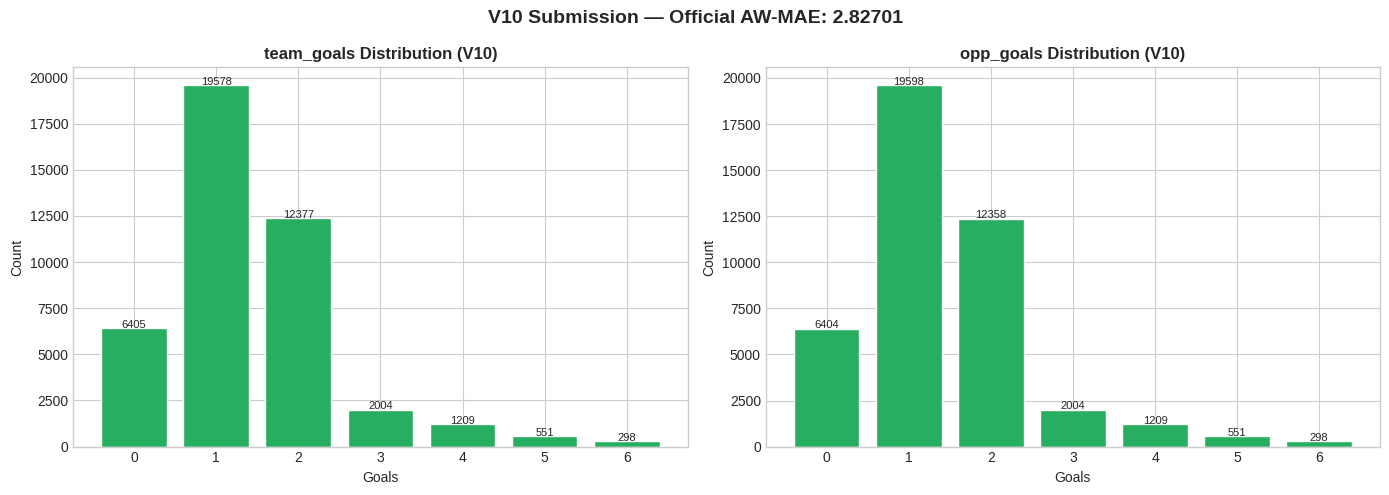

  V10 PIPELINE COMPLETE
  Baseline: 5.4669
  V10 FULL: 2.8270  ← submitted
  Oracle  : 0.000000
────────────────────────────────────────────────────────────────────────
  V10 New: multi-seed x3, windows 3/15/20, elo_win_prob,
           quality-adj features, nested-CV stacker, draw correction
  Draw correction: thr=0.35, lam_diff=0.30000000000000004, n_corrected=1264
  Models saved: ./models_v10/


In [24]:
submission = test_fe[['Id']].copy()
submission['team_goals'] = pred_team_int
submission['opp_goals']  = pred_opp_int

assert submission.isna().sum().sum() == 0, 'NaNs!'
assert (submission['team_goals'] >= 0).all()
assert (submission['opp_goals']  >= 0).all()
assert len(submission) == len(test)

submission.to_csv('submission_v10.csv', index=False)

sub_check = submission.merge(gt_map, on='Id', suffixes=('_pred','_true'))
tw_final  = test.set_index('Id').loc[sub_check['Id'],'tournament'].apply(get_tournament_weight).values
final_score = awmae_score(sub_check['team_goals_true'], sub_check['opp_goals_true'],
                           sub_check['team_goals_pred'], sub_check['opp_goals_pred'], weights=tw_final)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col in zip(axes, ['team_goals','opp_goals']):
    counts = submission[col].value_counts().sort_index().head(12)
    ax.bar(counts.index, counts.values, color='#27ae60', edgecolor='white')
    ax.set_title(f'{col} Distribution (V10)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Goals'); ax.set_ylabel('Count')
    for i, v in zip(counts.index, counts.values):
        ax.text(i, v+20, str(v), ha='center', fontsize=8)
plt.suptitle(f'V10 Submission — Official AW-MAE: {final_score:.5f}', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

print('='*72)
print('  V10 PIPELINE COMPLETE')
print('='*72)
print(f'  Baseline: {baseline_aw:.4f}')
print(f'  V10 FULL: {model_aw:.4f}  ← submitted')
print(f'  Oracle  : {oracle_aw:.6f}')
print(f'{"─"*72}')
print(f'  V10 New: multi-seed x{len(SEEDS)}, windows 3/15/20, elo_win_prob,')
print(f'           quality-adj features, nested-CV stacker, draw correction')
print(f'  Draw correction: thr={BEST_DRAW_PROB_THR}, lam_diff={BEST_LAM_DIFF_THR}, '
      f'n_corrected={n_draw_corrected}')
print(f'  Models saved: {MODEL_DIR}/')
print('='*72)
